# 02_prepare_splits.ipynb — Preparação Formal + Splits (Notebook Oficial 02)

## Objetivo
- Ler `data/processed/eda_schema_inferido.json`
- Recarregar `data/raw/lesions/GroundTruth.csv` com a mesma normalização do Notebook 01
- Formalizar o target (single-label multiclass a partir do one-hot)
- Limpar e validar:
  - remover linhas sem imagem válida
  - criar `image_stem` como ID estável
  - garantir 1 imagem por amostra (dedupe por stem)
- Gerar splits reprodutíveis:
  - `train.csv`, `val.csv`, `test.csv`
  - seed fixa
  - estratificação por classe quando possível (single-label)
- Gerar relatórios/artefatos:
  - `dataset_clean.csv`
  - `label_map.json`
  - `splits_report.json`
  - `target_config.json` (formalização do target + regras/políticas)

## Inputs
- `data/processed/eda_schema_inferido.json`
- `data/raw/lesions/GroundTruth.csv`
- `data/raw/lesions/images/`
- `data/raw/lesions/masks/` (opcional)

## Outputs (obrigatórios) em `data/processed/`
- `dataset_clean.csv`
- `train.csv`, `val.csv`, `test.csv`
- `label_map.json`
- `splits_report.json`
- `target_config.json`

## Reprodutibilidade
- Seed fixa registrada em `splits_report.json`


In [1]:
# =========================
# 02_prepare_splits.ipynb — Célula 01
# Setup + imports + seed
# =========================
from __future__ import annotations

import os
import re
import json
import csv
import math
import random
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

missing = []
try:
    import numpy as np
except Exception:
    missing.append("numpy")
try:
    import pandas as pd
except Exception:
    missing.append("pandas")

if missing:
    raise RuntimeError(
        "Dependências ausentes: "
        + ", ".join(missing)
        + "\n\nInstale com:\n"
        + "  pip install " + " ".join(missing) + "\n"
        + "ou (recomendado) instale via requirements do projeto."
    )

# Seed oficial do projeto (reprodutibilidade)
REPRO_SEED = 42
random.seed(REPRO_SEED)
np.random.seed(REPRO_SEED)
os.environ["PYTHONHASHSEED"] = str(REPRO_SEED)

print("OK — imports carregados.")
print("Seed fixa:", REPRO_SEED)


OK — imports carregados.
Seed fixa: 42


In [2]:
# =========================
# 02_prepare_splits.ipynb — Célula 02
# PROJECT_ROOT + paths oficiais + load schema
# =========================

def find_project_root(start: Path, required_rel: str = "data/raw/lesions/GroundTruth.csv", max_up: int = 10) -> Path:
    """
    Sobe diretórios a partir de `start` até encontrar o arquivo required_rel.
    """
    start = start.resolve()
    cur = start
    for _ in range(max_up + 1):
        if (cur / required_rel).exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(
        f"Não foi possível encontrar PROJECT_ROOT contendo '{required_rel}' a partir de: {start}"
    )

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "lesions"
IMAGES_DIR = RAW_DIR / "images"
MASKS_DIR = RAW_DIR / "masks"
GT_CSV = RAW_DIR / "GroundTruth.csv"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Garantir pastas de saída
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SCHEMA_PATH = PROCESSED_DIR / "eda_schema_inferido.json"
assert IMAGES_DIR.exists(), f"IMAGES_DIR não existe: {IMAGES_DIR}"
assert GT_CSV.exists(), f"GroundTruth.csv não existe: {GT_CSV}"
assert SCHEMA_PATH.exists(), f"Schema não existe (rode Notebook 01): {SCHEMA_PATH}"

schema = json.loads(SCHEMA_PATH.read_text(encoding="utf-8"))

# Gate mínimo: chaves esperadas do schema
if "columns" not in schema:
    raise RuntimeError("Schema inválido: chave 'columns' ausente em eda_schema_inferido.json")

cols = schema["columns"]
required = ["image_col", "label_cols", "mode"]
for k in required:
    if k not in cols:
        raise RuntimeError(f"Schema inválido: columns['{k}'] ausente")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("GT_CSV      :", GT_CSV)
print("SCHEMA      :", SCHEMA_PATH)
print("PROCESSED   :", PROCESSED_DIR)

print("\n=== Schema (colunas principais) ===")
print("image_col       :", cols.get("image_col"))
print("mask_col        :", cols.get("mask_col"))
print("mode            :", cols.get("mode"))
print("target_encoding :", cols.get("target_encoding"))
print("label_cols      :", cols.get("label_cols"))
print("meta_cols_count :", len(cols.get("meta_cols", []) or []))


PROJECT_ROOT: C:\Users\win\Documents\GitHub\pimple
GT_CSV      : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\GroundTruth.csv
SCHEMA      : C:\Users\win\Documents\GitHub\pimple\data\processed\eda_schema_inferido.json
PROCESSED   : C:\Users\win\Documents\GitHub\pimple\data\processed

=== Schema (colunas principais) ===
image_col       : image
mask_col        : None
mode            : single_label
target_encoding : one_hot_multiclass
label_cols      : ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
meta_cols_count : 0


In [3]:
# =========================
# 02_prepare_splits.ipynb — Célula 03
# Leitura do CSV + normalização (igual Notebook 01)
# =========================

def sniff_csv_sep(path: Path, default: str = ",") -> str:
    try:
        sample = path.read_text(encoding="utf-8", errors="ignore")[:4096]
        dialect = csv.Sniffer().sniff(sample, delimiters=[",", ";", "\t", "|"])
        return dialect.delimiter
    except Exception:
        return default

def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"\s+", "_", c)
    c = re.sub(r"[^a-z0-9_]+", "", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

sep = sniff_csv_sep(GT_CSV, default=",")
df_raw = pd.read_csv(GT_CSV, sep=sep, low_memory=False)

df = df_raw.copy()
df.columns = [normalize_colname(c) for c in df.columns]

print("CSV lido com sep =", repr(sep))
print("df.shape:", df.shape)
print("cols (primeiras):", list(df.columns)[:20], ("..." if len(df.columns) > 20 else ""))

image_col = cols["image_col"]
label_cols = cols["label_cols"] or []
meta_cols = cols.get("meta_cols", []) or []
mask_col = cols.get("mask_col")

if image_col not in df.columns:
    raise RuntimeError(
        f"image_col do schema ('{image_col}') não existe no CSV normalizado.\n"
        f"Colunas disponíveis (normalizadas): {df.columns.tolist()}"
    )

missing_labels = [c for c in label_cols if c not in df.columns]
if missing_labels:
    raise RuntimeError(
        "label_cols do schema não existem no CSV normalizado:\n"
        + "\n".join([f"- {c}" for c in missing_labels])
    )

print("\nOK — CSV recarregado e normalizado.")
print("image_col:", image_col)
print("label_cols (n):", len(label_cols))


CSV lido com sep = ','
df.shape: (10015, 8)
cols (primeiras): ['image', 'mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc'] 

OK — CSV recarregado e normalizado.
image_col: image
label_cols (n): 7


In [4]:
# =========================
# 02_prepare_splits.ipynb — Célula 04
# Index do disco + resolvers oficiais
# =========================

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

# Inclui _segmentation / -segmentation (padrão real)
MASK_SUFFIXES = [
    "", "_mask", "-mask", "_seg", "-seg",
    "_segmentation", "-segmentation",
    "_lesion", "_lesion_mask", "_binary", "_annotation", "_ann"
]

def list_files_by_ext(root: Path, exts: set[str]) -> List[Path]:
    if not root.exists():
        return []
    out: List[Path] = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            out.append(p)
    return out

def build_stem_index(files: List[Path]) -> Dict[str, List[Path]]:
    idx: Dict[str, List[Path]] = {}
    for p in files:
        stem = p.stem.strip().lower()
        idx.setdefault(stem, []).append(p)
    return idx

def safe_str(x: object) -> str:
    return "" if pd.isna(x) else str(x)

def norm_to_stem(v: str) -> str:
    """
    Normaliza valor do CSV para stem:
    - 'ISIC_0001.jpg' => 'isic_0001'
    - 'images/ISIC_0001.jpg' => 'isic_0001'
    - 'ISIC_0001' => 'isic_0001'
    """
    v = (v or "").strip()
    if not v:
        return ""
    p = Path(v)
    name = p.name
    p2 = Path(name)
    if p2.suffix.lower() in (IMG_EXTS | MASK_EXTS):
        return p2.stem.strip().lower()
    return name.strip().lower()

# Index do disco
image_files = list_files_by_ext(IMAGES_DIR, IMG_EXTS)
mask_files = list_files_by_ext(MASKS_DIR, MASK_EXTS)

images_by_stem = build_stem_index(image_files)
masks_by_stem = build_stem_index(mask_files)

disk_dup_images_count = int(sum(1 for _, v in images_by_stem.items() if len(v) > 1))
disk_dup_masks_count = int(sum(1 for _, v in masks_by_stem.items() if len(v) > 1))

print("=== Index do disco ===")
print("IMAGES_DIR:", IMAGES_DIR)
print("MASKS_DIR :", MASKS_DIR)
print("image_files:", len(image_files))
print("mask_files :", len(mask_files))
print("duplicatas no disco (images_by_stem>1):", disk_dup_images_count)
print("duplicatas no disco (masks_by_stem>1) :", disk_dup_masks_count)

def resolve_image_path(value_or_stem: str) -> Optional[Path]:
    v = (value_or_stem or "").strip()
    if not v:
        return None
    p = Path(v)

    # absoluto com extensão
    if p.is_absolute() and p.exists() and p.suffix.lower() in IMG_EXTS:
        return p

    # com extensão (talvez veio "images/xxx.jpg")
    if p.suffix.lower() in IMG_EXTS:
        cand = IMAGES_DIR / p.name
        if cand.exists():
            return cand
        st = p.stem.strip().lower()
        lst = images_by_stem.get(st, [])
        return sorted(lst)[0] if lst else None

    # sem extensão => stem
    st = norm_to_stem(v)
    lst = images_by_stem.get(st, [])
    return sorted(lst)[0] if lst else None

def resolve_mask_path_from_csv(value: str) -> Optional[Path]:
    v = (value or "").strip()
    if not v:
        return None
    p = Path(v)

    if p.is_absolute() and p.exists() and p.suffix.lower() in MASK_EXTS:
        return p

    if p.suffix.lower() in MASK_EXTS:
        cand = MASKS_DIR / p.name
        if cand.exists():
            return cand
        st = p.stem.strip().lower()
        lst = masks_by_stem.get(st, [])
        return sorted(lst)[0] if lst else None

    return None

def resolve_mask_path_by_stem(stem: str) -> Optional[Path]:
    s = (stem or "").strip().lower()
    if not s:
        return None

    # direta
    if s in masks_by_stem:
        return sorted(masks_by_stem[s])[0]

    # sufixos
    for suf in MASK_SUFFIXES:
        key = (s + suf).strip().lower()
        if key in masks_by_stem:
            return sorted(masks_by_stem[key])[0]

    # se o stem já veio com sufixo, tenta remover
    for suf in MASK_SUFFIXES:
        if suf and s.endswith(suf):
            base = s[: -len(suf)]
            if base in masks_by_stem:
                return sorted(masks_by_stem[base])[0]

    return None

def to_rel(p: Optional[Path]) -> str:
    if p is None:
        return ""
    try:
        return str(p.relative_to(PROJECT_ROOT))
    except Exception:
        return str(p)


=== Index do disco ===
IMAGES_DIR: C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\images
MASKS_DIR : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\masks
image_files: 10015
mask_files : 10015
duplicatas no disco (images_by_stem>1): 0
duplicatas no disco (masks_by_stem>1) : 0


In [5]:
# =========================
# 02_prepare_splits.ipynb — Célula 05
# Gate do schema + dataset_clean + target formal
# =========================

MODE = cols.get("mode")
TARGET_ENCODING = cols.get("target_encoding")

# Gate preparado para evolução (sem quebrar o notebook)
SUPPORTED = {
    ("single_label", "one_hot_multiclass"),
    ("multi_label", "multi_hot"),
    ("multi_label", "one_hot_multiclass"),
}
if (MODE, TARGET_ENCODING) not in SUPPORTED:
    raise RuntimeError(
        "Schema/target não suportado por este notebook.\n"
        f"Encontrado: mode={MODE!r}, target_encoding={TARGET_ENCODING!r}\n"
        f"Suportado: {sorted(list(SUPPORTED))}"
    )

print(f"OK — modo atual: {MODE} | encoding: {TARGET_ENCODING}")

# Este notebook implementa formalização completa para o caso atual:
# single_label + one_hot_multiclass (one-hot soma=1).
# Se no futuro for multi-label, o split e métricas precisam de política específica.
if not (MODE == "single_label" and TARGET_ENCODING == "one_hot_multiclass"):
    raise RuntimeError(
        "Caminho multi-label ainda não está implementado neste notebook.\n"
        "O gate aceita o schema para não quebrar o pipeline, mas a lógica precisa ser estendida."
    )

# --- Resolver imagem e criar image_stem ---
df_work = df.copy()

df_work["image_stem"] = df_work[image_col].map(lambda x: norm_to_stem(safe_str(x)))
df_work["image_path_abs"] = df_work[image_col].map(lambda x: resolve_image_path(safe_str(x)))
df_work["image_path"] = df_work["image_path_abs"].map(to_rel)

# Remover linhas sem imagem válida
before = len(df_work)
df_work = df_work[df_work["image_path_abs"].notna()].copy()
removed_no_img = before - len(df_work)

# Garantir que o arquivo existe
before2 = len(df_work)
df_work = df_work[df_work["image_path_abs"].map(lambda p: Path(p).exists())].copy()
removed_not_exists = before2 - len(df_work)

# --- Máscara (opcional) ---
df_work["mask_path_abs"] = None

if mask_col and (mask_col in df_work.columns):
    df_work["mask_path_abs"] = df_work[mask_col].map(lambda x: resolve_mask_path_from_csv(safe_str(x)))
    missing_mask = df_work["mask_path_abs"].isna()
    df_work.loc[missing_mask, "mask_path_abs"] = df_work.loc[missing_mask, "image_stem"].map(resolve_mask_path_by_stem)
else:
    df_work["mask_path_abs"] = df_work["image_stem"].map(resolve_mask_path_by_stem)

df_work["mask_path"] = df_work["mask_path_abs"].map(to_rel)

# --- Validar one-hot e criar target ---
one_hot_raw = df_work[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
one_hot = (one_hot_raw > 0.5).astype(int)

row_sum = one_hot.sum(axis=1)
invalid_sum = (row_sum != 1)
n_invalid_sum = int(invalid_sum.sum())

# Remover linhas sem target válido (soma != 1)
before3 = len(df_work)
df_work = df_work[~invalid_sum].copy()
one_hot = one_hot.loc[df_work.index]
removed_bad_target = before3 - len(df_work)

# Formalização
target_index = one_hot.values.argmax(axis=1).astype(int)
idx_to_label = list(label_cols)  # ordem oficial = schema
df_work["target_index"] = target_index
df_work["target_label"] = [idx_to_label[i] for i in target_index]

# --- Dedupe por image_stem (1 imagem por amostra) ---
before4 = len(df_work)
dup_mask = df_work.duplicated(subset=["image_stem"], keep="first")
n_dup_rows = int(dup_mask.sum())
df_work = df_work[~dup_mask].copy()

# --- Colunas finais do dataset_clean ---
final_cols = []
for c in ["image_stem", "image_path", "mask_path", "target_index", "target_label"]:
    if c in df_work.columns:
        final_cols.append(c)

# mantém labels one-hot (traceabilidade)
final_cols += [c for c in label_cols if c in df_work.columns]

# mantém meta_cols se existirem
final_cols += [c for c in meta_cols if c in df_work.columns and c not in final_cols]

dataset_clean = df_work[final_cols].reset_index(drop=True)

print("=== Limpeza / validação ===")
print("linhas removidas (sem imagem resolvida):", removed_no_img)
print("linhas removidas (path não existe):", removed_not_exists)
print("linhas removidas (one-hot soma != 1):", removed_bad_target)
print("linhas removidas (duplicatas por image_stem):", n_dup_rows)
print("dataset_clean.shape:", dataset_clean.shape)

# Checagens finais
assert dataset_clean["image_stem"].isna().sum() == 0, "image_stem não pode ter NaN"
assert dataset_clean["image_stem"].duplicated().sum() == 0, "dataset_clean não pode ter image_stem duplicado"
assert dataset_clean["image_path"].astype(str).str.len().min() > 0, "image_path não pode ser vazio"
assert dataset_clean[label_cols].sum(axis=1).eq(1).all(), "one-hot precisa somar 1 por linha"

print("\nDistribuição (target_label):")
print(dataset_clean["target_label"].value_counts())


OK — modo atual: single_label | encoding: one_hot_multiclass
=== Limpeza / validação ===
linhas removidas (sem imagem resolvida): 0
linhas removidas (path não existe): 0
linhas removidas (one-hot soma != 1): 0
linhas removidas (duplicatas por image_stem): 0
dataset_clean.shape: (10015, 12)

Distribuição (target_label):
target_label
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [6]:
# =========================
# 02_prepare_splits.ipynb — Célula EXTRA
# target_config.json (target_definition + regras + políticas)
# =========================

TARGET_CFG_PATH = PROCESSED_DIR / "target_config.json"

# Política explícita para classes raras (não filtra aqui; apenas registra)
RARE_POLICY = {
    "definition": "classe rara = contagem_total < rare_total_threshold OR contagem_no_treino < rare_train_threshold",
    "rare_total_threshold": 20,
    "rare_train_threshold": 10,
    "action": "keep_all",  # opções futuras: merge_to_other | reweight_loss | oversample | etc.
    "notes": "Nesta etapa, NÃO removemos classes raras; apenas registramos para orientar baselines/experimentos."
}

# Política explícita para máscaras (segmentação opcional)
mask_coverage_ratio = float((dataset_clean.get("mask_path", pd.Series([""]*len(dataset_clean)))
                            .astype(str).str.strip() != "").mean()) if len(dataset_clean) else 0.0

MASK_POLICY = {
    "segmentation_considered": True,
    "mask_required_for_inclusion": False,  # aqui NÃO filtramos dataset por máscara
    "resolution_strategy": {
        "from_csv_if_available": bool(mask_col and (mask_col in df.columns)),
        "fallback_by_stem": True,
        "suffixes_used": MASK_SUFFIXES,
    },
    "mask_coverage_ratio_in_clean": mask_coverage_ratio,
    "notes": "Máscaras são opcionais no dataset_clean; usadas apenas se a trilha de segmentação for escolhida."
}

TARGET_DEFINITION = {
    "task": "classification",
    "mode": MODE,  # single_label
    "source_encoding": TARGET_ENCODING,  # one_hot_multiclass
    "label_cols": list(label_cols),
    "meta_cols": list(meta_cols),
    "image_col": image_col,
    "derived_columns": {
        "image_stem": "ID estável derivado do image_col (stem, lowercase).",
        "target_label": "classe final derivada de argmax(one-hot).",
        "target_index": "índice inteiro alinhado à ordem de label_cols."
    },
    "one_hot_rules": {
        "binarization_threshold": 0.5,
        "row_sum_required": 1,
        "invalid_rows_removed": True
    }
}

CLEANING_RULES = [
    {
        "rule": "remove_rows_without_resolved_image",
        "description": "Remove linhas cujo resolve_image_path falhou (path None).",
        "removed_rows": int(removed_no_img),
    },
    {
        "rule": "remove_rows_with_nonexistent_image_path",
        "description": "Remove linhas cujo arquivo não existe no disco.",
        "removed_rows": int(removed_not_exists),
    },
    {
        "rule": "remove_rows_with_invalid_target_sum",
        "description": "Remove linhas cujo one-hot soma != 1 (single-label).",
        "removed_rows": int(removed_bad_target),
    },
    {
        "rule": "dedupe_by_image_stem_keep_first",
        "description": "Garante 1 imagem por amostra. Remove duplicatas de image_stem (keep='first').",
        "removed_rows": int(n_dup_rows),
    },
]

class_counts = dataset_clean["target_label"].value_counts().to_dict() if "target_label" in dataset_clean.columns else {}
rare_total = [k for k, v in class_counts.items() if int(v) < int(RARE_POLICY["rare_total_threshold"])]

target_config = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "paths": {
        "schema": str(SCHEMA_PATH),
        "ground_truth_csv": str(GT_CSV),
        "images_dir": str(IMAGES_DIR),
        "masks_dir": str(MASKS_DIR),
        "processed_dir": str(PROCESSED_DIR),
    },
    "target_definition": TARGET_DEFINITION,
    "cleaning_rules": CLEANING_RULES,
    "rare_class_policy": RARE_POLICY,
    "mask_policy": MASK_POLICY,
    "observations": {
        "class_counts_in_clean": {str(k): int(v) for k, v in class_counts.items()},
        "rare_classes_by_total_threshold": rare_total,
    }
}

TARGET_CFG_PATH.write_text(json.dumps(target_config, indent=2, ensure_ascii=False), encoding="utf-8")
print("OK — target_config salvo em:", TARGET_CFG_PATH)
print("mask_coverage_ratio_in_clean:", mask_coverage_ratio)
print("rare_classes_by_total_threshold:", rare_total)


OK — target_config salvo em: C:\Users\win\Documents\GitHub\pimple\data\processed\target_config.json
mask_coverage_ratio_in_clean: 1.0
rare_classes_by_total_threshold: []


In [7]:
# =========================
# 02_prepare_splits.ipynb — Célula 06
# Splits reprodutíveis (estratificado quando possível)
# =========================

SPLIT_CFG = {
    "seed": REPRO_SEED,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,
    "use_group_split": False,   # ative se quiser evitar leakage por lesion_id/patient_id
    "group_col": None,          # auto-detect se use_group_split=True
}

# Auto-detect group_col
if SPLIT_CFG["use_group_split"]:
    candidates = [c for c in ["lesion_id", "patient_id", "lesionid", "patientid"] if c in dataset_clean.columns]
    chosen = None
    for c in candidates:
        if dataset_clean[c].nunique(dropna=True) < len(dataset_clean):
            chosen = c
            break
    SPLIT_CFG["group_col"] = chosen

y = dataset_clean["target_label"].astype(str).values
n = len(dataset_clean)

train_frac = float(SPLIT_CFG["train_frac"])
val_frac   = float(SPLIT_CFG["val_frac"])
test_frac  = float(SPLIT_CFG["test_frac"])

if not math.isclose(train_frac + val_frac + test_frac, 1.0, rel_tol=0, abs_tol=1e-6):
    raise RuntimeError("train_frac + val_frac + test_frac precisa somar 1.0")

def random_split_indices(n: int, train_frac: float, val_frac: float, test_frac: float, seed: int):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    n_test = int(round(n * test_frac))
    n_val  = int(round(n * val_frac))
    n_train = n - n_val - n_test
    i_test = idx[:n_test]
    i_val  = idx[n_test:n_test+n_val]
    i_train = idx[n_test+n_val:]
    return i_train, i_val, i_test

def stratified_split_indices(y: np.ndarray, train_frac: float, val_frac: float, test_frac: float, seed: int):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    classes, y_inv = np.unique(y, return_inverse=True)
    counts = np.bincount(y_inv, minlength=len(classes))

    n_test = int(round(n * test_frac))
    n_val  = int(round(n * val_frac))
    n_train = n - n_val - n_test

    desired_val  = counts * val_frac
    desired_test = counts * test_frac

    alloc_val  = np.floor(desired_val).astype(int)
    alloc_test = np.floor(desired_test).astype(int)

    def adjust_alloc(alloc: np.ndarray, desired: np.ndarray, target_total: int, cap: np.ndarray):
        cur = int(alloc.sum())
        frac = desired - np.floor(desired)
        if cur < target_total:
            need = target_total - cur
            order = np.argsort(-frac)
            for j in order:
                if need == 0:
                    break
                if alloc[j] < cap[j]:
                    alloc[j] += 1
                    need -= 1
        elif cur > target_total:
            extra = cur - target_total
            order = np.argsort(frac)
            for j in order:
                if extra == 0:
                    break
                if alloc[j] > 0:
                    alloc[j] -= 1
                    extra -= 1
        return alloc

    alloc_val  = adjust_alloc(alloc_val,  desired_val,  n_val,  counts.copy())
    alloc_test = adjust_alloc(alloc_test, desired_test, n_test, counts.copy())

    # Força pelo menos 1 no train quando possível
    alloc_train = counts - alloc_val - alloc_test
    for j in range(len(classes)):
        if counts[j] == 0:
            continue
        if alloc_train[j] == 0:
            if alloc_val[j] > 0:
                alloc_val[j] -= 1
                alloc_train[j] += 1
            elif alloc_test[j] > 0:
                alloc_test[j] -= 1
                alloc_train[j] += 1

    alloc_train = counts - alloc_val - alloc_test
    if (alloc_train < 0).any():
        return None

    idx_train, idx_val, idx_test = [], [], []
    for cls_i in range(len(classes)):
        idx = np.where(y_inv == cls_i)[0]
        rng.shuffle(idx)

        n_te = int(alloc_test[cls_i])
        n_va = int(alloc_val[cls_i])

        idx_test.extend(idx[:n_te].tolist())
        idx_val.extend(idx[n_te:n_te+n_va].tolist())
        idx_train.extend(idx[n_te+n_va:].tolist())

    idx_train = np.array(idx_train, dtype=int)
    idx_val   = np.array(idx_val, dtype=int)
    idx_test  = np.array(idx_test, dtype=int)

    rng.shuffle(idx_train)
    rng.shuffle(idx_val)
    rng.shuffle(idx_test)

    return idx_train, idx_val, idx_test

def group_split_indices(groups: np.ndarray, train_frac: float, val_frac: float, test_frac: float, seed: int):
    rng = np.random.default_rng(seed)
    groups = np.asarray(groups)
    uniq = pd.unique(groups)
    uniq = np.array([g for g in uniq if pd.notna(g)], dtype=object)
    rng.shuffle(uniq)

    group_to_idx = {}
    for i, g in enumerate(groups):
        group_to_idx.setdefault(g, []).append(i)

    total = len(groups)
    target_test = int(round(total * test_frac))
    target_val  = int(round(total * val_frac))

    test_groups, val_groups, train_groups = set(), set(), set()
    cur_test = 0
    cur_val = 0

    for g in uniq:
        g_count = len(group_to_idx.get(g, []))
        if cur_test < target_test:
            test_groups.add(g); cur_test += g_count
        elif cur_val < target_val:
            val_groups.add(g); cur_val += g_count
        else:
            train_groups.add(g)

    idx_test = [i for g in test_groups for i in group_to_idx.get(g, [])]
    idx_val  = [i for g in val_groups for i in group_to_idx.get(g, [])]
    idx_train = [i for g in train_groups for i in group_to_idx.get(g, [])]

    idx_train = np.array(idx_train, dtype=int)
    idx_val   = np.array(idx_val, dtype=int)
    idx_test  = np.array(idx_test, dtype=int)

    rng.shuffle(idx_train); rng.shuffle(idx_val); rng.shuffle(idx_test)
    return idx_train, idx_val, idx_test

use_group = bool(SPLIT_CFG["use_group_split"]) and (SPLIT_CFG["group_col"] is not None)
split_method = "group" if use_group else "stratified"

if use_group:
    gcol = SPLIT_CFG["group_col"]
    groups = dataset_clean[gcol].values
    i_train, i_val, i_test = group_split_indices(groups, train_frac, val_frac, test_frac, SPLIT_CFG["seed"])
else:
    out = stratified_split_indices(y, train_frac, val_frac, test_frac, SPLIT_CFG["seed"])
    if out is None:
        split_method = "random_fallback"
        i_train, i_val, i_test = random_split_indices(n, train_frac, val_frac, test_frac, SPLIT_CFG["seed"])
    else:
        i_train, i_val, i_test = out

train_df = dataset_clean.iloc[i_train].copy().reset_index(drop=True)
val_df   = dataset_clean.iloc[i_val].copy().reset_index(drop=True)
test_df  = dataset_clean.iloc[i_test].copy().reset_index(drop=True)

print("=== Splits ===")
print("método:", split_method)
if use_group:
    print("group_col:", SPLIT_CFG["group_col"])
print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
print("seed:", SPLIT_CFG["seed"])

def assert_no_overlap(a: pd.DataFrame, b: pd.DataFrame, key: str = "image_stem"):
    inter = set(a[key]).intersection(set(b[key]))
    assert len(inter) == 0, f"Overlap detectado em {key}: {len(inter)}"

assert_no_overlap(train_df, val_df)
assert_no_overlap(train_df, test_df)
assert_no_overlap(val_df, test_df)

def assert_paths_exist(df_: pd.DataFrame):
    miss = 0
    for p in df_["image_path"].astype(str).tolist():
        if not (PROJECT_ROOT / p).exists():
            miss += 1
    assert miss == 0, f"{miss} image_path não existem no disco."

assert_paths_exist(train_df)
assert_paths_exist(val_df)
assert_paths_exist(test_df)

print("\nDistribuições por split (target_label):")
print("train:\n", train_df["target_label"].value_counts())
print("\nval:\n", val_df["target_label"].value_counts())
print("\ntest:\n", test_df["target_label"].value_counts())


=== Splits ===
método: stratified
train: (7011, 12) val: (1502, 12) test: (1502, 12)
seed: 42

Distribuições por split (target_label):
train:
 target_label
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc      100
df         81
Name: count, dtype: int64

val:
 target_label
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       21
df         17
Name: count, dtype: int64

test:
 target_label
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       21
df         17
Name: count, dtype: int64


In [8]:
# =========================
# 02_prepare_splits.ipynb — Célula EXTRA
# Missingness por split
# =========================

def missingness_table(df_: pd.DataFrame) -> Dict[str, Dict[str, float]]:
    """
    % missing por coluna:
    - NaN conta
    - string vazia "" também conta (somente colunas object)
    """
    out = {}
    for c in df_.columns:
        s = df_[c]
        if s.dtype == object:
            miss = s.isna() | (s.astype(str).str.strip() == "")
        else:
            miss = s.isna()
        out[str(c)] = {"missing_pct": float(miss.mean()), "missing_count": int(miss.sum())}
    return out

missingness = {
    "dataset_clean": missingness_table(dataset_clean),
    "train": missingness_table(train_df),
    "val": missingness_table(val_df),
    "test": missingness_table(test_df),
}

# resumo rápido
def top_missing(miss_dict: Dict[str, Dict[str, float]], k: int = 10):
    return sorted(miss_dict.items(), key=lambda kv: (-kv[1]["missing_pct"], kv[0]))[:k]

for split in ["train", "val", "test"]:
    print(f"\n=== Top missing ({split}) ===")
    for col, info in top_missing(missingness[split], k=10):
        if info["missing_pct"] > 0:
            print(f"{col:30s}  {info['missing_pct']*100:6.2f}%  (n={info['missing_count']})")



=== Top missing (train) ===

=== Top missing (val) ===

=== Top missing (test) ===


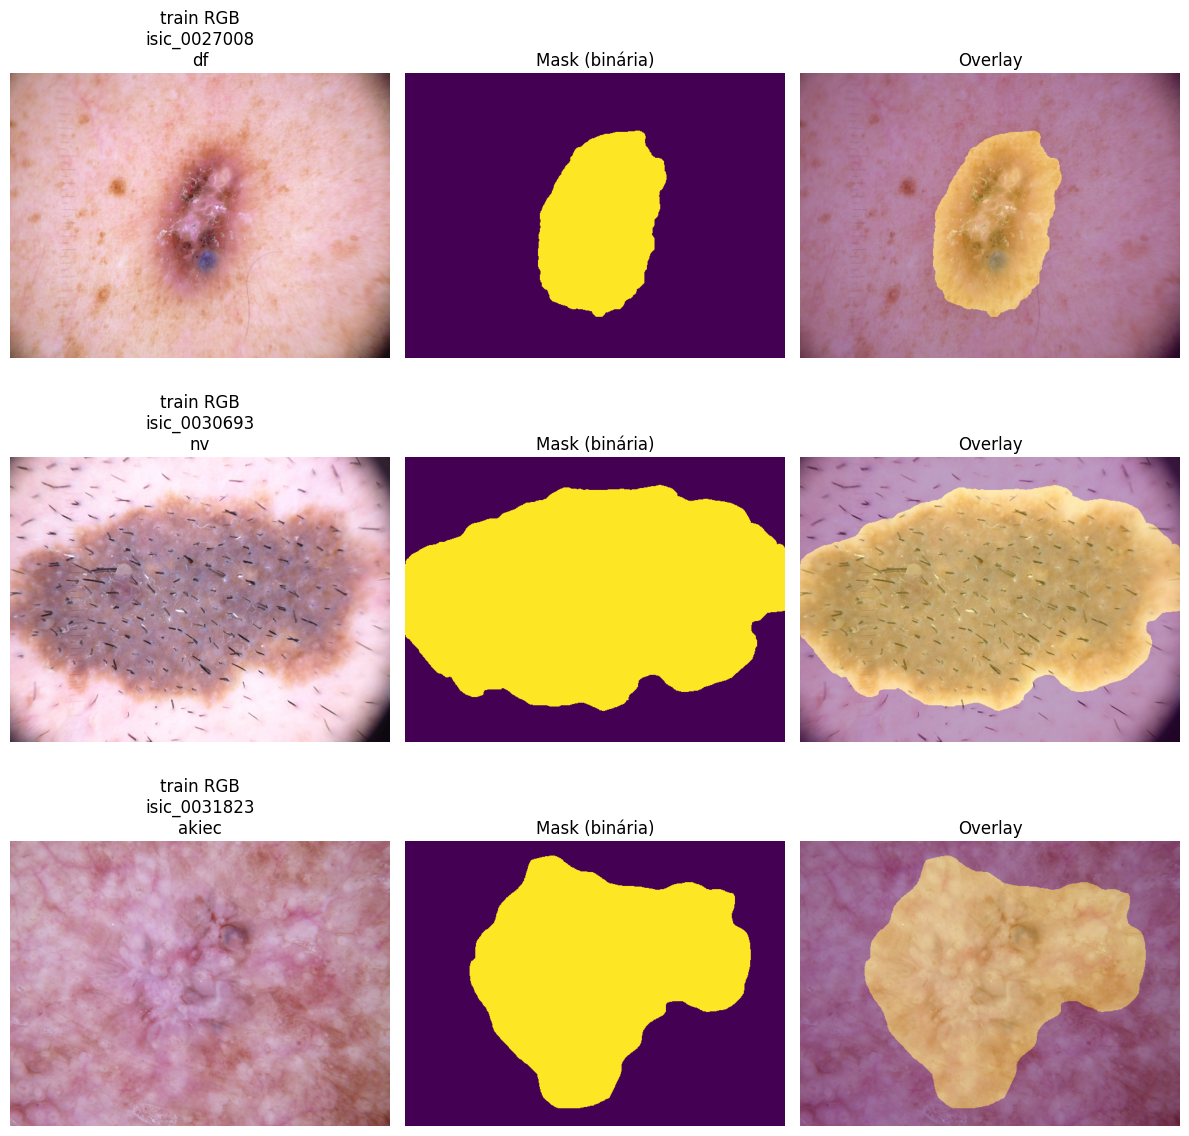

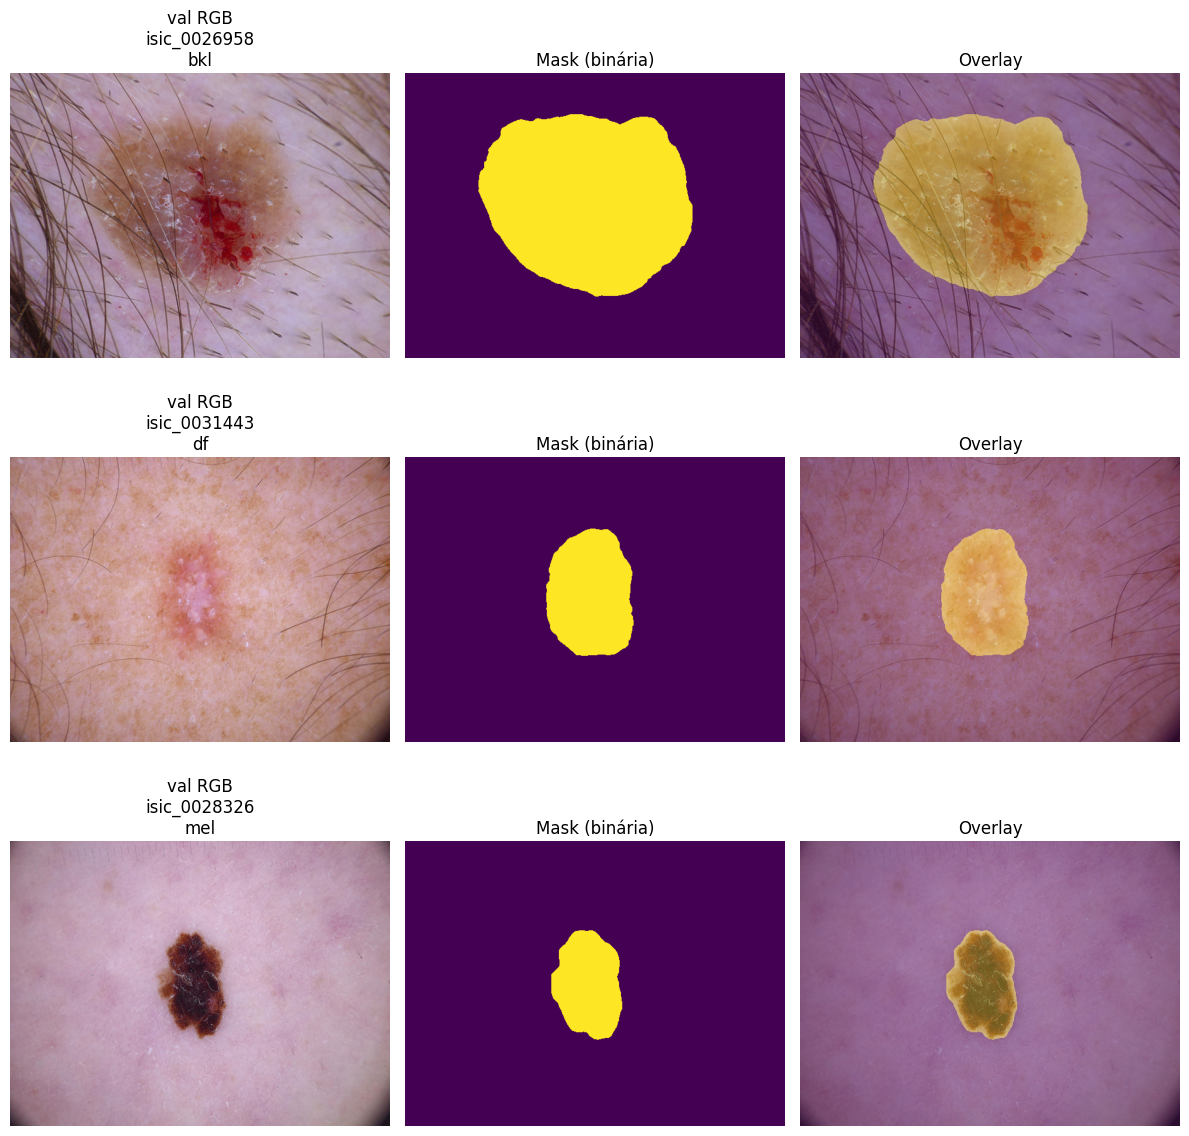

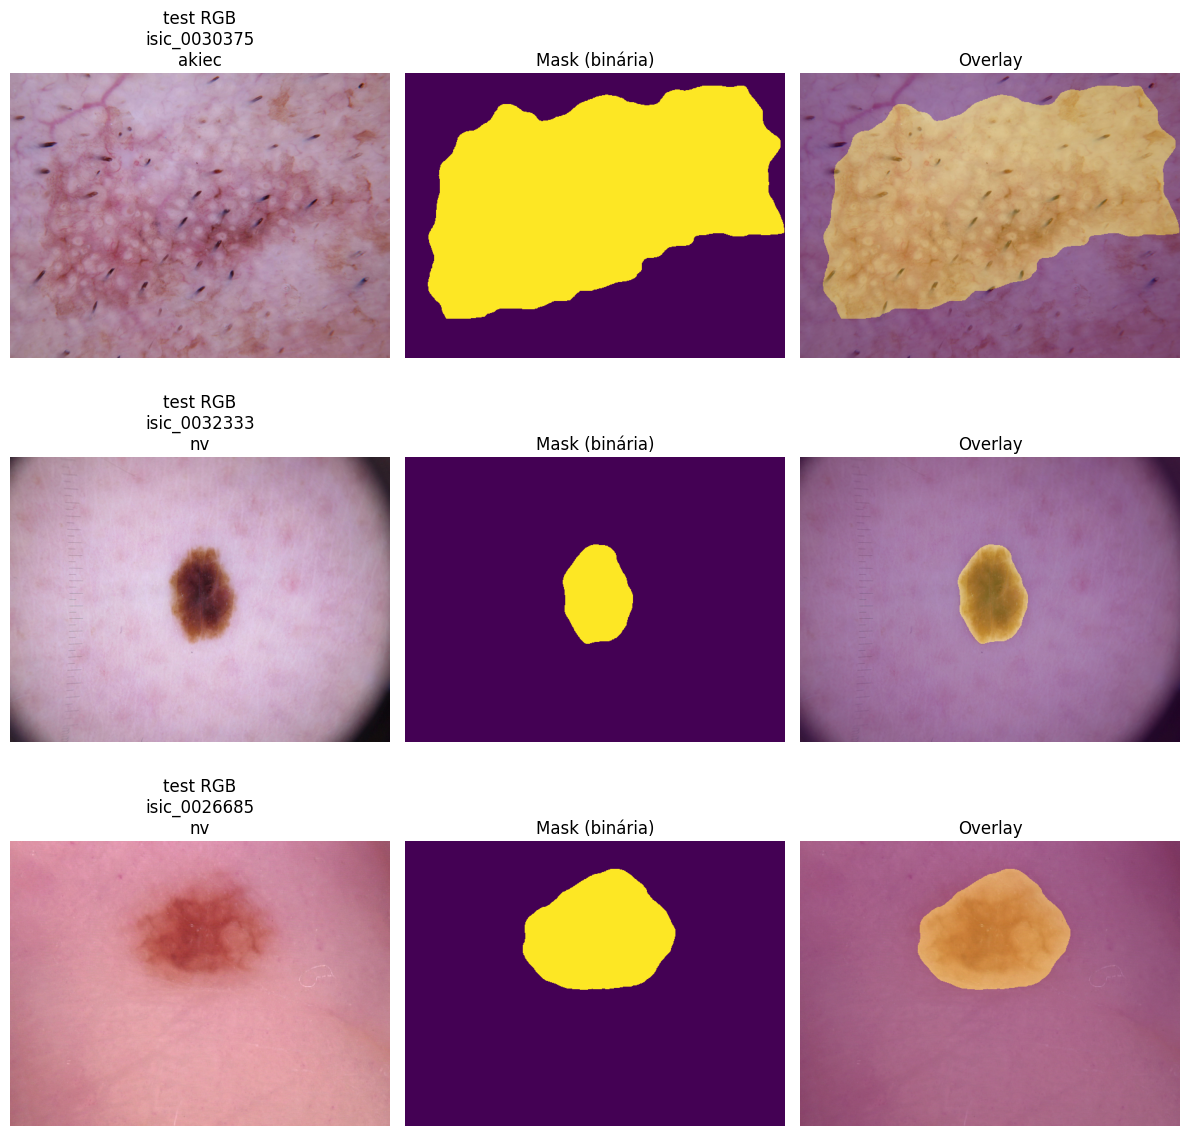

Sanity stems: {
  "train": [
    "isic_0027008",
    "isic_0030693",
    "isic_0031823"
  ],
  "val": [
    "isic_0026958",
    "isic_0031443",
    "isic_0028326"
  ],
  "test": [
    "isic_0030375",
    "isic_0032333",
    "isic_0026685"
  ]
}


In [9]:
# =========================
# 02_prepare_splits.ipynb — Célula EXTRA
# Sanity visual por split (train/val/test)
# =========================

missing_vis = []
try:
    from PIL import Image
except Exception:
    missing_vis.append("pillow")
try:
    import matplotlib.pyplot as plt
except Exception:
    missing_vis.append("matplotlib")

if missing_vis:
    raise RuntimeError(
        "Dependências ausentes para visualização: " + ", ".join(missing_vis) +
        "\nInstale com:\n  pip install " + " ".join(missing_vis)
    )

def load_rgb(rel_path: str) -> np.ndarray:
    img = Image.open(PROJECT_ROOT / rel_path).convert("RGB")
    return np.array(img)

def load_mask(rel_path: str, target_hw: Optional[Tuple[int, int]] = None) -> Optional[np.ndarray]:
    if not rel_path or str(rel_path).strip() == "":
        return None
    p = PROJECT_ROOT / rel_path
    if not p.exists():
        return None
    m = Image.open(p).convert("L")
    if target_hw is not None:
        m = m.resize((target_hw[1], target_hw[0]), resample=Image.NEAREST)  # (W,H)
    arr = np.array(m)
    arr = (arr > 0).astype(np.uint8)
    return arr

def show_samples(split_name: str, df_: pd.DataFrame, n_samples: int = 3, seed: int = 42) -> List[str]:
    if len(df_) == 0:
        print(f"[{split_name}] vazio.")
        return []
    rng = np.random.default_rng(seed)
    take = min(n_samples, len(df_))
    idx = rng.choice(len(df_), size=take, replace=False)

    picked = []
    fig, axes = plt.subplots(take, 3, figsize=(12, 4 * take))
    if take == 1:
        axes = np.array([axes])

    for r, i in enumerate(idx):
        row = df_.iloc[int(i)]
        picked.append(str(row["image_stem"]))

        img = load_rgb(row["image_path"])
        h, w = img.shape[:2]
        m = load_mask(row.get("mask_path", ""), target_hw=(h, w))

        axes[r, 0].imshow(img); axes[r, 0].axis("off")
        axes[r, 0].set_title(f"{split_name} RGB\n{row['image_stem']}\n{row.get('target_label','')}")

        if m is None:
            axes[r, 1].imshow(img); axes[r, 1].axis("off")
            axes[r, 1].set_title("Mask: ausente")
            axes[r, 2].imshow(img); axes[r, 2].axis("off")
            axes[r, 2].set_title("Overlay: sem máscara")
        else:
            axes[r, 1].imshow(m); axes[r, 1].axis("off")
            axes[r, 1].set_title("Mask (binária)")
            axes[r, 2].imshow(img); axes[r, 2].imshow(m, alpha=0.35); axes[r, 2].axis("off")
            axes[r, 2].set_title("Overlay")

    plt.tight_layout()
    plt.show()
    return picked

sanity_samples = {
    "train": show_samples("train", train_df, n_samples=3, seed=REPRO_SEED),
    "val":   show_samples("val",   val_df,   n_samples=3, seed=REPRO_SEED + 1),
    "test":  show_samples("test",  test_df,  n_samples=3, seed=REPRO_SEED + 2),
}
print("Sanity stems:", json.dumps(sanity_samples, indent=2, ensure_ascii=False))


In [10]:
# =========================
# 02_prepare_splits.ipynb — Célula 07 
# target_config.json (target_definition + label_cols + meta_cols + image_col + regras + políticas)
# =========================

TARGET_CFG_PATH = PROCESSED_DIR / "target_config.json"

# Política explícita para classes raras (não filtra aqui; apenas registra)
RARE_POLICY = {
    "definition": "classe rara = contagem_total < rare_total_threshold OR contagem_no_treino < rare_train_threshold",
    "rare_total_threshold": 20,
    "rare_train_threshold": 10,
    "action": "keep_all",
    "notes": "Nesta etapa, NÃO removemos classes raras; apenas registramos para orientar baselines/experimentos."
}

# Política explícita para máscaras (segmentação opcional)
mask_coverage_ratio = float(
    (dataset_clean.get("mask_path", pd.Series([""] * len(dataset_clean)))
     .astype(str).str.strip() != "").mean()
) if len(dataset_clean) else 0.0

MASK_POLICY = {
    "segmentation_considered": True,
    "mask_required_for_inclusion": False,
    "resolution_strategy": {
        "from_csv_if_available": bool(mask_col and (mask_col in df.columns)),
        "fallback_by_stem": True,
        "suffixes_used": MASK_SUFFIXES,
    },
    "mask_coverage_ratio_in_clean": mask_coverage_ratio,
    "notes": "Máscaras são opcionais no dataset_clean; usadas apenas se a trilha de segmentação for escolhida."
}

# ✅ target_definition exigida pelo planejamento (inclui image_col + meta_cols)
TARGET_DEFINITION = {
    "task": "classification",
    "mode": MODE,
    "source_encoding": TARGET_ENCODING,
    "image_col": str(image_col),          # ✅ exigido
    "label_cols": list(label_cols),
    "meta_cols": list(meta_cols),         # ✅ exigido
    "mask_col": (str(mask_col) if mask_col else ""),
    "derived_columns": {
        "image_stem": "ID estável derivado do image_col (stem, lowercase).",
        "target_label": "classe final derivada de argmax(one-hot).",
        "target_index": "índice inteiro alinhado à ordem de label_cols.",
        "image_path": "path relativo ao PROJECT_ROOT",
        "mask_path": "path relativo ao PROJECT_ROOT (opcional)"
    },
    "one_hot_rules": {
        "binarization_threshold": 0.5,
        "row_sum_required": 1,
        "invalid_rows_removed": True
    }
}

# Regras de limpeza (formalizadas)
CLEANING_RULES = [
    {
        "rule": "remove_rows_without_resolved_image",
        "description": "Remove linhas cujo resolve_image_path falhou (path None).",
        "removed_rows": int(removed_no_img),
    },
    {
        "rule": "remove_rows_with_nonexistent_image_path",
        "description": "Remove linhas cujo arquivo não existe no disco.",
        "removed_rows": int(removed_not_exists),
    },
    {
        "rule": "remove_rows_with_invalid_target_sum",
        "description": "Remove linhas cujo one-hot soma != 1 (single-label).",
        "removed_rows": int(removed_bad_target),
    },
    {
        "rule": "dedupe_by_image_stem_keep_first",
        "description": "Garante 1 imagem por amostra. Remove duplicatas de image_stem (keep='first').",
        "removed_rows": int(n_dup_rows),
    },
]

# Observações / classes raras
class_counts = dataset_clean["target_label"].value_counts().to_dict() if "target_label" in dataset_clean.columns else {}
rare_total = [k for k, v in class_counts.items() if int(v) < int(RARE_POLICY["rare_total_threshold"])]

target_config = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "paths": {
        "schema": str(SCHEMA_PATH),
        "ground_truth_csv": str(GT_CSV),
        "images_dir": str(IMAGES_DIR),
        "masks_dir": str(MASKS_DIR),
        "processed_dir": str(PROCESSED_DIR),
    },
    "target_definition": TARGET_DEFINITION,
    "cleaning_rules": CLEANING_RULES,
    "rare_class_policy": RARE_POLICY,
    "mask_policy": MASK_POLICY,
    "observations": {
        "class_counts_in_clean": {str(k): int(v) for k, v in class_counts.items()},
        "rare_classes_by_total_threshold": rare_total,
    }
}

TARGET_CFG_PATH.write_text(json.dumps(target_config, indent=2, ensure_ascii=False), encoding="utf-8")

print("OK — target_config salvo em:", TARGET_CFG_PATH)
print("image_col:", image_col)
print("meta_cols (n):", len(meta_cols))
print("mask_coverage_ratio_in_clean:", mask_coverage_ratio)
print("rare_classes_by_total_threshold:", rare_total)


OK — target_config salvo em: C:\Users\win\Documents\GitHub\pimple\data\processed\target_config.json
image_col: image
meta_cols (n): 0
mask_coverage_ratio_in_clean: 1.0
rare_classes_by_total_threshold: []


In [11]:
# =========================
# 02_prepare_splits.ipynb — Célula 08 
# Missingness por split
# =========================

def missingness_table(df_: pd.DataFrame) -> Dict[str, Dict[str, float]]:
    out = {}
    for c in df_.columns:
        s = df_[c]
        if s.dtype == object:
            miss = s.isna() | (s.astype(str).str.strip() == "")
        else:
            miss = s.isna()
        out[str(c)] = {"missing_pct": float(miss.mean()), "missing_count": int(miss.sum())}
    return out

missingness = {
    "dataset_clean": missingness_table(dataset_clean),
    "train": missingness_table(train_df),
    "val": missingness_table(val_df),
    "test": missingness_table(test_df),
}

def top_missing(miss_dict: Dict[str, Dict[str, float]], k: int = 10):
    return sorted(miss_dict.items(), key=lambda kv: (-kv[1]["missing_pct"], kv[0]))[:k]

for split in ["train", "val", "test"]:
    print(f"\n=== Top missing ({split}) ===")
    for col, info in top_missing(missingness[split], k=10):
        if info["missing_pct"] > 0:
            print(f"{col:30s}  {info['missing_pct']*100:6.2f}%  (n={info['missing_count']})")



=== Top missing (train) ===

=== Top missing (val) ===

=== Top missing (test) ===


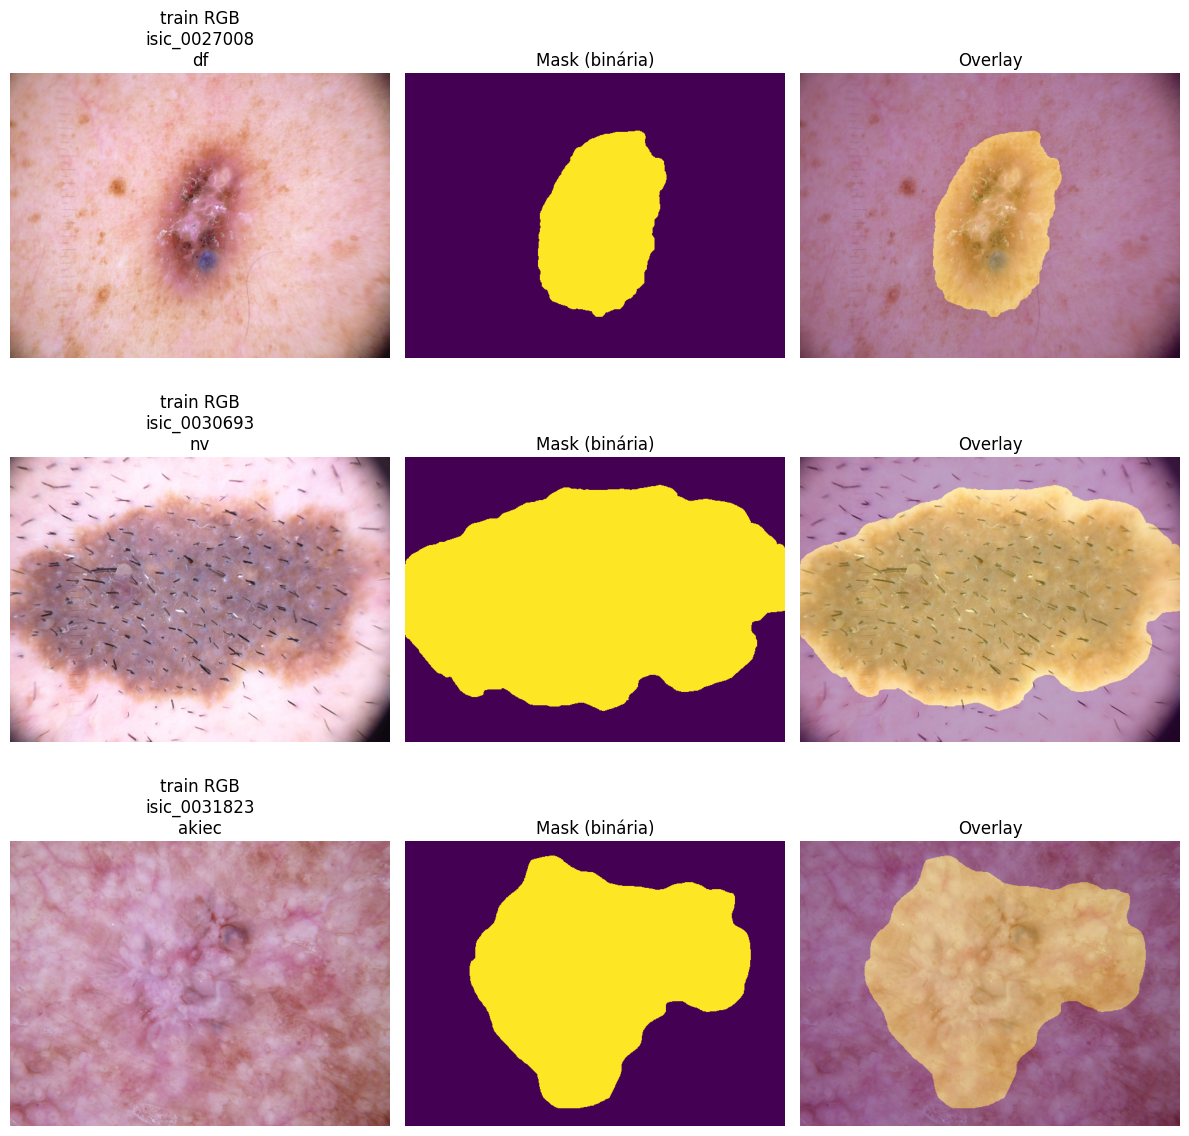

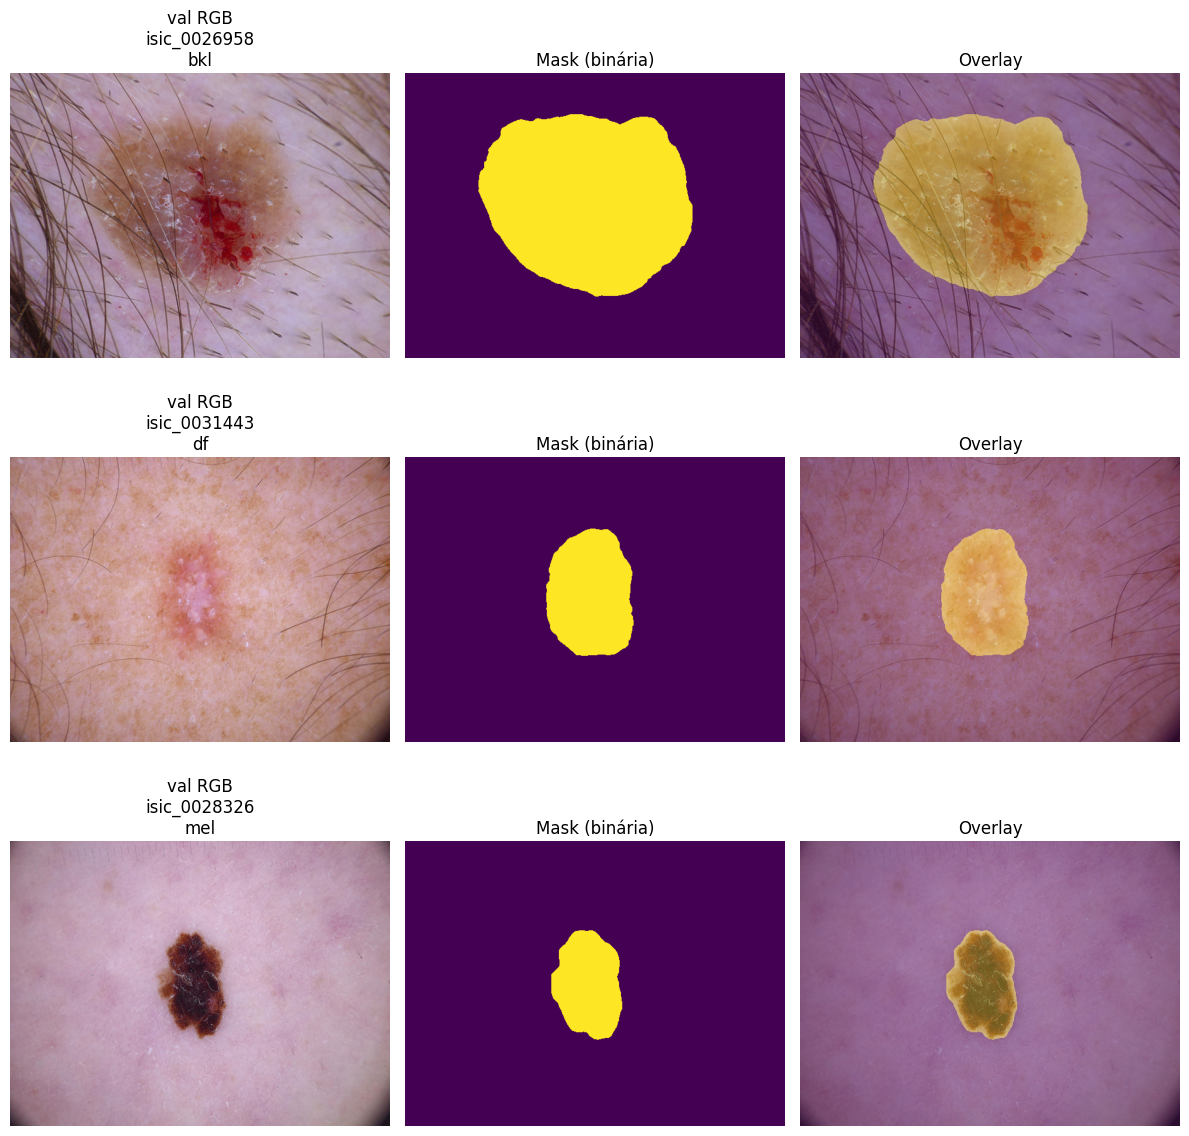

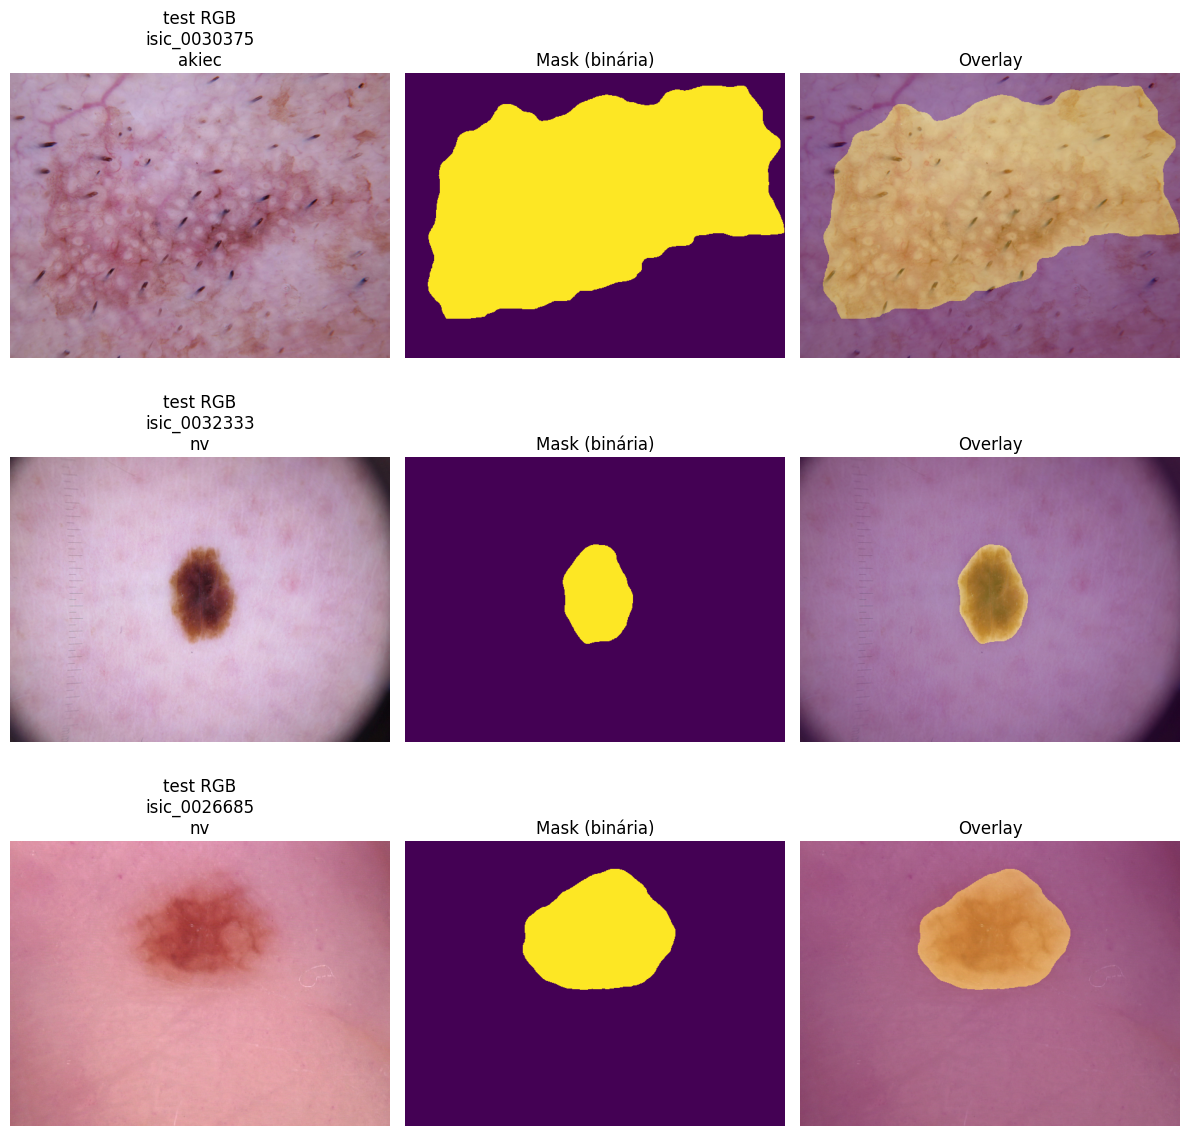

Sanity stems: {
  "train": [
    "isic_0027008",
    "isic_0030693",
    "isic_0031823"
  ],
  "val": [
    "isic_0026958",
    "isic_0031443",
    "isic_0028326"
  ],
  "test": [
    "isic_0030375",
    "isic_0032333",
    "isic_0026685"
  ]
}


In [12]:
# =========================
# 02_prepare_splits.ipynb — Célula 09
# Sanity visual por split (train/val/test)
# =========================

missing_vis = []
try:
    from PIL import Image
except Exception:
    missing_vis.append("pillow")
try:
    import matplotlib.pyplot as plt
except Exception:
    missing_vis.append("matplotlib")

if missing_vis:
    raise RuntimeError(
        "Dependências ausentes para visualização: " + ", ".join(missing_vis) +
        "\nInstale com:\n  pip install " + " ".join(missing_vis)
    )

def load_rgb(rel_path: str) -> np.ndarray:
    img = Image.open(PROJECT_ROOT / rel_path).convert("RGB")
    return np.array(img)

def load_mask(rel_path: str, target_hw: Optional[Tuple[int, int]] = None) -> Optional[np.ndarray]:
    if not rel_path or str(rel_path).strip() == "":
        return None
    p = PROJECT_ROOT / rel_path
    if not p.exists():
        return None
    m = Image.open(p).convert("L")
    if target_hw is not None:
        m = m.resize((target_hw[1], target_hw[0]), resample=Image.NEAREST)
    arr = (np.array(m) > 0).astype(np.uint8)
    return arr

def show_samples(split_name: str, df_: pd.DataFrame, n_samples: int = 3, seed: int = 42) -> List[str]:
    if len(df_) == 0:
        print(f"[{split_name}] vazio.")
        return []
    rng = np.random.default_rng(seed)
    take = min(n_samples, len(df_))
    idx = rng.choice(len(df_), size=take, replace=False)

    picked = []
    fig, axes = plt.subplots(take, 3, figsize=(12, 4 * take))
    if take == 1:
        axes = np.array([axes])

    for r, i in enumerate(idx):
        row = df_.iloc[int(i)]
        picked.append(str(row["image_stem"]))

        img = load_rgb(row["image_path"])
        h, w = img.shape[:2]
        m = load_mask(row.get("mask_path", ""), target_hw=(h, w))

        axes[r, 0].imshow(img); axes[r, 0].axis("off")
        axes[r, 0].set_title(f"{split_name} RGB\n{row['image_stem']}\n{row.get('target_label','')}")

        if m is None:
            axes[r, 1].imshow(img); axes[r, 1].axis("off"); axes[r, 1].set_title("Mask: ausente")
            axes[r, 2].imshow(img); axes[r, 2].axis("off"); axes[r, 2].set_title("Overlay: sem máscara")
        else:
            axes[r, 1].imshow(m); axes[r, 1].axis("off"); axes[r, 1].set_title("Mask (binária)")
            axes[r, 2].imshow(img); axes[r, 2].imshow(m, alpha=0.35); axes[r, 2].axis("off"); axes[r, 2].set_title("Overlay")

    plt.tight_layout()
    plt.show()
    return picked

sanity_samples = {
    "train": show_samples("train", train_df, n_samples=3, seed=REPRO_SEED),
    "val":   show_samples("val",   val_df,   n_samples=3, seed=REPRO_SEED + 1),
    "test":  show_samples("test",  test_df,  n_samples=3, seed=REPRO_SEED + 2),
}
print("Sanity stems:", json.dumps(sanity_samples, indent=2, ensure_ascii=False))


In [13]:
# =========================
# 02_prepare_splits.ipynb — Célula 10A
# Montar label_map + splits_report (inclui target_config + missingness + sanity)
# =========================

# Fallbacks (para não quebrar se alguma célula opcional não rodou)
_target_cfg = str(TARGET_CFG_PATH) if "TARGET_CFG_PATH" in globals() else ""
_missingness = missingness if "missingness" in globals() else {}
_sanity = sanity_samples if "sanity_samples" in globals() else {}

# label_map.json (sempre gerar para contrato e export futuro)
label_map = {
    "index_to_label": list(label_cols),
    "label_to_index": {lbl: int(i) for i, lbl in enumerate(label_cols)},
    "mode": MODE,
    "target_encoding": TARGET_ENCODING,
    "generated_at": datetime.now().isoformat(timespec="seconds"),
}

def dist_counts(df_: pd.DataFrame) -> Dict[str, int]:
    vc = df_["target_label"].value_counts()
    return {str(k): int(v) for k, v in vc.items()}

splits_report = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "seed": int(SPLIT_CFG["seed"]),
    "split_cfg": SPLIT_CFG,
    "split_method": split_method,

    "paths": {
        "project_root": str(PROJECT_ROOT),
        "gt_csv": str(GT_CSV),
        "schema": str(SCHEMA_PATH),
        "images_dir": str(IMAGES_DIR),
        "masks_dir": str(MASKS_DIR),
        "processed_dir": str(PROCESSED_DIR),
        "target_config": _target_cfg,   # ✅ ponto 4: registrado
    },

    "schema_snapshot": {
        "image_col": image_col,
        "mask_col": mask_col,
        "label_cols": list(label_cols),
        "meta_cols": list(meta_cols),
        "mode": MODE,
        "target_encoding": TARGET_ENCODING,
    },

    "cleaning": {
        "removed_no_img_resolved": int(removed_no_img),
        "removed_path_not_exists": int(removed_not_exists),
        "removed_bad_target_sum": int(removed_bad_target),
        "removed_dup_image_stem": int(n_dup_rows),
        "disk_dup_images_count": int(disk_dup_images_count) if "disk_dup_images_count" in globals() else None,
        "disk_dup_masks_count": int(disk_dup_masks_count) if "disk_dup_masks_count" in globals() else None,
    },

    "counts": {
        "dataset_clean": int(len(dataset_clean)),
        "train": int(len(train_df)),
        "val": int(len(val_df)),
        "test": int(len(test_df)),
    },

    "distributions": {
        "dataset_clean": dist_counts(dataset_clean),
        "train": dist_counts(train_df),
        "val": dist_counts(val_df),
        "test": dist_counts(test_df),
    },

    "missingness": _missingness,            # ✅ ponto 4: incluído
    "sanity_visual_samples": _sanity,       # ✅ ponto 4: incluído

    "integrity_checks": {
        "no_overlap_by_image_stem": True,
        "all_image_paths_exist": True,
        "one_hot_sum_is_1": True,
    },
}

print("OK — splits_report montado.")
print("target_config path:", _target_cfg if _target_cfg else "(não definido)")
print("missingness keys:", list(_missingness.keys()) if isinstance(_missingness, dict) else "(não dict)")
print("sanity keys:", list(_sanity.keys()) if isinstance(_sanity, dict) else "(não dict)")


OK — splits_report montado.
target_config path: C:\Users\win\Documents\GitHub\pimple\data\processed\target_config.json
missingness keys: ['dataset_clean', 'train', 'val', 'test']
sanity keys: ['train', 'val', 'test']


In [14]:
# =========================
# 02_prepare_splits.ipynb — Célula 10B
# Salvar dataset_clean + splits + label_map + splits_report
# =========================

DATASET_CLEAN_PATH = PROCESSED_DIR / "dataset_clean.csv"
TRAIN_PATH = PROCESSED_DIR / "train.csv"
VAL_PATH = PROCESSED_DIR / "val.csv"
TEST_PATH = PROCESSED_DIR / "test.csv"
LABEL_MAP_PATH = PROCESSED_DIR / "label_map.json"
SPLITS_REPORT_PATH = PROCESSED_DIR / "splits_report.json"

dataset_clean.to_csv(DATASET_CLEAN_PATH, index=False, encoding="utf-8")
train_df.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
val_df.to_csv(VAL_PATH, index=False, encoding="utf-8")
test_df.to_csv(TEST_PATH, index=False, encoding="utf-8")

LABEL_MAP_PATH.write_text(json.dumps(label_map, indent=2, ensure_ascii=False), encoding="utf-8")
SPLITS_REPORT_PATH.write_text(json.dumps(splits_report, indent=2, ensure_ascii=False), encoding="utf-8")

print("=== OK — Artefatos salvos ===")
print("dataset_clean :", DATASET_CLEAN_PATH)
print("train         :", TRAIN_PATH)
print("val           :", VAL_PATH)
print("test          :", TEST_PATH)
print("label_map     :", LABEL_MAP_PATH)
print("splits_report :", SPLITS_REPORT_PATH)
print("target_config :", (TARGET_CFG_PATH if "TARGET_CFG_PATH" in globals() else "(não definido)"))


=== OK — Artefatos salvos ===
dataset_clean : C:\Users\win\Documents\GitHub\pimple\data\processed\dataset_clean.csv
train         : C:\Users\win\Documents\GitHub\pimple\data\processed\train.csv
val           : C:\Users\win\Documents\GitHub\pimple\data\processed\val.csv
test          : C:\Users\win\Documents\GitHub\pimple\data\processed\test.csv
label_map     : C:\Users\win\Documents\GitHub\pimple\data\processed\label_map.json
splits_report : C:\Users\win\Documents\GitHub\pimple\data\processed\splits_report.json
target_config : C:\Users\win\Documents\GitHub\pimple\data\processed\target_config.json
